### This workbook uses the outputs from the `dorado` particle tracking model and computes potential particle "uptake".
This script coincides with the manuscript _ and processes the `dorado` results for 24,000 particles seeded in Wax Lake Delta of coastal Louisiana, USA.

Potential uptake is computed for each particle based on a simple first-order decay rate and the particle residence times. 

A detailed explanation of the modeling process can be found in the manuscript.

Any user would need to explicitly clone the dorado repo that is currently found on Eleanor Henson's GitHub (https://github.com/eghenson/dorado), hopefully merged with parent dorado repository soon.

Required files to run:
- "../input_data/dorado_inputs/ROI_grid.npy"
- "../input_data/uptake_inputs/bathySC.npy"
- "../input_data/uptake_inputs/cutoff_raster.tif"
- "../input_data/uptake_inputs/Particle_Q.csv"
- "../results/dorado_results/FC_baseline/FC_wd.pkl" (gzipped)
- "../results/dorado_results/SC_baseline/SC_wd" (gzipped)
- "../results/dorado_results/FC_baseline/particles_per_timestep_FC.npy"
- "../results/dorado_results/SC_baseline/particles_per_timestep_SC.npy"

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import pickle
import sys
import rasterio
import gzip

# Define the path to the cloned dorado - this is just where mine lived 
dorado_repo = os.path.abspath(os.path.join("../../", "dorado"))

# Add the path to sys.path if it's not already there
if dorado_repo not in sys.path:
    sys.path.append(dorado_repo)

# Import the desired module
from dorado import particle_track as pt
from dorado import routines as drt

Assign input variables that are constant throughout both seasonal simulations. User should change the directories accordingly (pointing to the dorado results).

In [2]:
# -------------------------------------------
# Input variables
# -------------------------------------------
scenario = "SC"  # 'FC' or 'SC', depending on your model scenario of fall or spring
base_dir = "../"
base_input_dir = f"{base_dir}/input_data/"
total_particles = "24000" # baseline scenario

## Define inputs for uptake analysis
model_timestep = 1800 # seconds, 30 minutes
initial_conc = 0.95 # mg/L, median value found in Knights et al. 2020 
k_hr = 0.01  # hr⁻¹, median value that Knights et al. 20202 found in one island of WLD
k_sec = k_hr /3600

# Define the path to the 'Uptake' folder to store results
base_outfolder = f"{base_dir}/results/uptake_results"
if not os.path.exists(base_outfolder):
    os.makedirs(base_outfolder)
    print(f"Created directory: {base_outfolder}")

# Load the ROI grid used in dorado and bathy grid from the numpy files
ROI_grid = np.load(f"{base_input_dir}/dorado_inputs/ROI_grid.npy")
bathy_grid = np.load(f"{base_input_dir}/uptake_inputs/bathy{scenario}.npy") # for consistencies sake, I added both, but bathy doesn't change across the seasons
raster_size = bathy_grid.shape


Load `dorado` outputs as pkl files and create a new output folder based on the season being evaluated.

Opening both seasons `dorado` pkl files can take a big chunk of computer RAM -- here I process separately

In [3]:
# -------------------------------------------
# Load dorado outputs --- 
# User would have to adjust these paths to where their saved results from the `dorado_add_ROI.ipynb` script
# -------------------------------------------
if scenario == "FC":
    FC_basepath = (f"{base_dir}/results/dorado_results/{scenario}_baseline/")
    with gzip.open(os.path.join(FC_basepath, "FC_wd.pkl"), "rb") as f:
            fc_base_wd = pickle.load(f)
    FC_particles = np.load(os.path.join(FC_basepath, f"particles_per_timestep_{scenario}.npy"))
    
    # initialize walk data and particles for model
    walk_data = fc_base_wd
    particles_per_step_array = FC_particles

else:
    SC_basepath = (f"{base_dir}/results/dorado_results/{scenario}_baseline/")
    with gzip.open(os.path.join(SC_basepath, "SC_wd.pkl"), "rb") as f:
            sc_base_wd = pickle.load(f)
    SC_particles = np.load(os.path.join(SC_basepath, f"particles_per_timestep_{scenario}.npy"))

    #initialize walk data and particles for model
    walk_data = sc_base_wd
    particles_per_step_array = SC_particles

Import a binary raster to cutoff uptake outside of the delta. 

*This cutoff was only applied in the simulations that included in-stream uptake, along with the uptake in the vegetated ROI.

In our case for WLD, this cutoff boundary was based on the DEM and did not change for each seasonal simulation.

Loaded cutoff raster: ..//input_data//uptake_inputs/cutoff_raster.tif
Created uptake_mask (boolean) from binary raster.


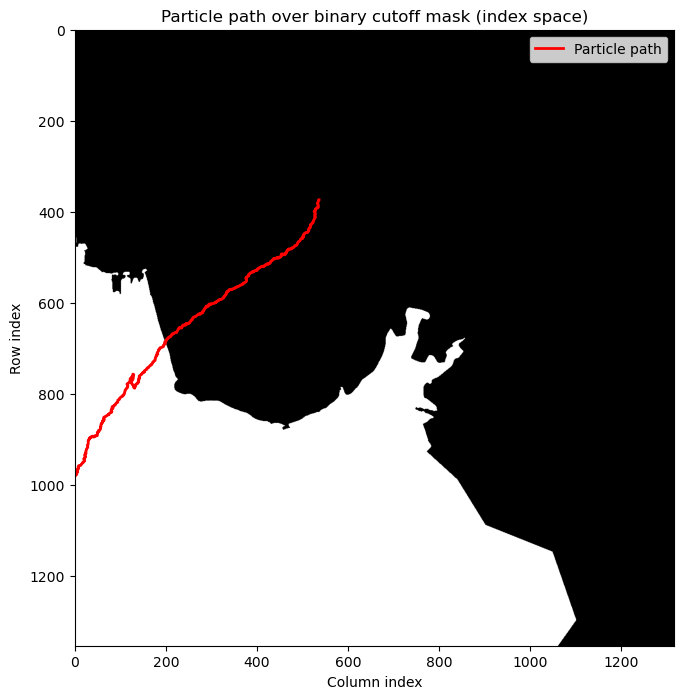

In [4]:
# -------------------------------------------
# Load raster for off-shore uptake cutoff
# -------------------------------------------
cutoff_path = f"{base_input_dir}/uptake_inputs/cutoff_raster.tif"
if not os.path.exists(cutoff_path):
    raise FileNotFoundError(f"{cutoff_path} not found in working directory: {os.getcwd()}")

with rasterio.open(cutoff_path) as src:
    uptake_cutoff = src.read(1)        # first band as numpy array
    uptake_transform = src.transform
    uptake_crs = src.crs

print("Loaded cutoff raster:", cutoff_path)

# If raster is binary (0/1), create a boolean mask
unique_vals = np.unique(uptake_cutoff)
if set(unique_vals).issubset({0, 1}):
    uptake_mask = uptake_cutoff.astype(bool)
    print("Created uptake_mask (boolean) from binary raster.")

# Warn if shape doesn't match expected raster_size
if 'raster_size' in globals() and uptake_cutoff.shape != raster_size:
    print(f"cutoff raster shape {uptake_cutoff.shape} != expected raster_size {raster_size}")

# Pick a particle to test
p = 0
xinds = walk_data["xinds"][p]
yinds = walk_data["yinds"][p]

# Plot in index space (array coordinates)
plt.figure(figsize=(10, 8))
plt.imshow(uptake_mask, cmap="gray")  
plt.plot(yinds, xinds, "-r", lw=2, label="Particle path")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.title("Particle path over binary cutoff mask (index space)")
plt.legend()
plt.show()

### This section begins to initialize the variables required for uptake calculations.
First, we read in the input discharge data at the particle seeding transect, which was calculated with the `ANUGA` hydrodynamic outputs.

The discharge is then used to flux normalize the number of particles in each seeding cohort.

Various dictionaries are initialized to track potential particle uptake.

#### NOTE: Do not run this block if just performing the senstitivity to the first-order decay rate, k-analysis. For that analysis, the dictionaries are initialized within the loop.

In [ ]:
# -------------------------------------------
# Load discharge series for the first day
# -------------------------------------------
discharge_series = pd.read_csv(
    f"{base_input_dir}/uptake_inputs/Particle_Q.csv",
    usecols=[scenario],  # "FC" or "SC"
    header=0
).squeeze()  # pandas Series, length = num_steps (48)

num_steps = len(discharge_series)
total_particles = len(walk_data["island_flags"])  # from the loaded combined walk_data
print("Total particles:", total_particles)
assert len(particles_per_step_array) == num_steps, "Mismatch between discharge series and particle counts"

# -------------------------------------------
# Create mapping of particle index -> seeding step
# -------------------------------------------
seeding_step_for_particle = []
for step, n_particles in enumerate(particles_per_step_array):
    seeding_step_for_particle.extend([step] * n_particles)

assert len(seeding_step_for_particle) == total_particles, \
    f"Mismatch: {len(seeding_step_for_particle)} vs {total_particles}"

# -------------------------------------------
# Compute initial particle mass per seeding step
# -------------------------------------------
step_mass_per_particle = {}
for step in range(num_steps):
    discharge = abs(discharge_series.iloc[step])  # m³/s
    total_mass_step = initial_conc * discharge * 1000 * model_timestep  # mg
    n_particles_step = particles_per_step_array[step]
    # Divide total mass by the number of particles actually seeded this step
    mass_per_particle = total_mass_step / n_particles_step if n_particles_step > 0 else 0
    step_mass_per_particle[step] = mass_per_particle

# -------------------------------------------
# Assign initial mass to each particle
# -------------------------------------------
particle_mass = {"mass": []}
for particle_idx, step in enumerate(seeding_step_for_particle):
    init_mass = step_mass_per_particle[step]
    steps = len(walk_data["island_flags"][particle_idx])
    # First timestep gets the initial mass, rest start at 0
    mass_list = [init_mass] + [0] * (steps - 1)
    particle_mass["mass"].append(mass_list)

# -------------------------------------------
# Initialize uptake_data dictionary
# -------------------------------------------
uptake_data = {
    key: [[0] * len(walk_data["xinds"][p]) for p in range(total_particles)]
    for key in ["percent_removed", "step_time", "cumulative_percent_removed"]
}

# -------------------------------------------
# Initialize total time in islands
# -------------------------------------------
time_in_island = {p: 0 for p in range(total_particles)}

# -------------------------------------------
# Optional sanity check
# -------------------------------------------
for step in range(num_steps):
    discharge = abs(discharge_series.iloc[step])
    total_mass_step = initial_conc * discharge * 1000 * model_timestep
    n_particles_step = particles_per_step_array[step]
    masses_this_step = [particle_mass["mass"][p][0] for p, s in enumerate(seeding_step_for_particle) if s == step]
    if n_particles_step > 0 and not np.isclose(sum(masses_this_step), total_mass_step):
        print(f"ERROR: Mass mismatch at step {step}: expected {total_mass_step}, got {sum(masses_this_step)}")

### Begin to process each particle's walk data:

1) The first computational block is for island-only vegetated removal within the ROI.

2) The second computational block is for the inclusion of in-stream uptake with vegetated removal. 

These cells are NOT meant to be run back to back - instead you would need to "clear" the uptake data and initial mass inputs. 

Aka, I would reccomend restarting the kernel between the uptake calculations and starting from the top.

In [ ]:
# -------------------------------------------
# Begin processing each particle's walk data 
# (islands-only, exponential decay)
# -------------------------------------------
# Guard against potential rerunning
assert uptake_data["percent_removed"][0][1] == 0 and \
       uptake_data["percent_removed"][-1][-1] == 0, \
    "uptake_data already contains results — re-run particle mass initialization cells before this block - better yet, restart kernel"

outfolder = os.path.join(base_outfolder, f"{scenario}_baseline")
if not os.path.exists(outfolder):
        os.makedirs(outfolder)
        print(f"Created directory: {outfolder}")
print(f"Storing uptake results here:{outfolder}")

for particle in range(len(walk_data["island_flags"])): # Loop through all particles
    for i in range(1, len(walk_data['xinds'][particle])): # Loop through every step for every particle
        island_flag = walk_data["island_flags"][particle][i]
        prev_island_flag = walk_data["island_flags"][particle][i - 1]
        
        # Compute incremental travel time
        travel_time = walk_data["travel_times"][particle][i] - walk_data["travel_times"][particle][i - 1]
        uptake_data["step_time"][particle][i] = travel_time
        
        # Track time in islands
        if (prev_island_flag + island_flag) == 2:
            time_in_island[particle] += travel_time
        elif (prev_island_flag + island_flag) == 1:
            time_in_island[particle] += 0.5 * travel_time
        
        # Get mass for current step
        mass_in = particle_mass["mass"][particle][i - 1] 

        # --- Exponential decay calculation ---
        if prev_island_flag == island_flag:
            # No transition
            k_eff = k_sec if island_flag == 1 else 0.0
            mass_out = mass_in * np.exp(-k_eff * travel_time)
        else:
            # Transition: split step in half
            dt_half = 0.5 * travel_time
            k_prev = k_sec if prev_island_flag == 1 else 0.0
            k_curr = k_sec if island_flag == 1 else 0.0
            mass_mid = mass_in * np.exp(-k_prev * dt_half)
            mass_out = mass_mid * np.exp(-k_curr * dt_half)

        # Clamp mass
        mass_out = max(0.0, mass_out)
        particle_mass["mass"][particle][i] = mass_out

        # Percent removed per step
        mass_removed = mass_in - mass_out
        percent_removed = (mass_removed / mass_in) * 100 if mass_in > 0 else 0.0
        uptake_data["percent_removed"][particle][i] = min(max(percent_removed, 0.0), 100.0)

        # Cumulative percent removed
        cumulative_percent = 100.0 * (1.0 - mass_out / particle_mass["mass"][particle][0])
        cumulative_percent = min(max(cumulative_percent, 0.0), 100.0)
        uptake_data["cumulative_percent_removed"][particle][i] = cumulative_percent

        if cumulative_percent >= 100.0 - 1e-9:
            print(f"⚠️ Particle {particle} fully removed by step {i}")
            
# # Save uptake_data (walks through each particle and each step - as dorado does) dictionaries 
# Optional save time_in_island (just total time in roi and particle number)

# Save each uptake dictionary
for key, value in uptake_data.items():
    filename = os.path.join(outfolder, f"Channel_uptake_data_{key}.pkl")
    with gzip.open(filename, "wb") as f:
        pickle.dump(value, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved all Channel uptake dictionaries for {scenario} in {outfolder}")

# with gzip.open(f'{outfolder}/{scenario}_baseline/{scenario}_time_in_island.pkl', 'wb') as f:
#     pickle.dump(time_in_island, f)

In [ ]:
# -------------------------------------------
# Begin processing each particle's walk data 
# (channel and islands)
# -------------------------------------------
# in-stream k-values are based on depth values (see Alexander et al. 2000- Nature)
# also added uptake cutoff for time spent outside of the delta

# Guard against potential rerunning
assert uptake_data["percent_removed"][0][1] == 0 and \
       uptake_data["percent_removed"][-1][-1] == 0, \
    "uptake_data already contains results — re-run particle mass initialization cells before this block - better yet, restart kernel"

outfolder = os.path.join(base_outfolder, f"{scenario}_channel_uptake")
print(f"Storing results here:{outfolder}")
if not os.path.exists(outfolder):
    os.makedirs(outfolder)
    print(f"Created directory: {outfolder}")

# Constants for non-island uptake rates (per day)
k_day_shallow = 0.15 # depth < 1 m             - CI ranges from 0.3-0.1 per day in Alexander et al. 2000
# measured k per day we used in islands = 0.24 per day, so we use that as a max value below
k_day_mid     = 0.10    # 1 m ≤ depth < 2 m      - CI ranges from 0.15-0.05 per day
k_day_deep    = 0.05   # depth ≥ 2 m ≤ 4 m       - CI ranges from 0.08 - 0.0001 per day

# Convert daily rates to per-second
k_sec_shallow = k_day_shallow / 86400
k_sec_mid     = k_day_mid / 86400
k_sec_deep    = k_day_deep / 86400

# Helper: get channel k from depth
def k_channel_for_depth(depth):
    if depth < 1.0:
        return k_sec_shallow
    elif depth < 2.0:
        return k_sec_mid
    elif depth <= 4.0:
        return k_sec_deep
    else:
        return 0.0  # deep water

# --- Loop through particles with cutoff mask check ---
for particle in range(len(walk_data["island_flags"])):
    for i in range(1, len(walk_data['xinds'][particle])):

        island_flag = walk_data["island_flags"][particle][i]
        travel_time = walk_data["travel_times"][particle][i] - walk_data["travel_times"][particle][i - 1]
        uptake_data["step_time"][particle][i] = travel_time
        
        prev_island_flag = walk_data["island_flags"][particle][i - 1]

        # Skip channel uptake if island_flag=0 (channel) **and** step is in cutoff region
        if island_flag == 0:
            x_idx = walk_data["xinds"][particle][i]
            y_idx = walk_data["yinds"][particle][i]

            # Make sure indices are integers for array access
            x_idx_int = int(round(x_idx))
            y_idx_int = int(round(y_idx))

            # Skip uptake if mask is True (i.e., outside delta / cutoff region)
            if uptake_mask[x_idx_int, y_idx_int]:
                k_eff = 0.0  # no channel uptake here
            else:
                depth_curr = walk_data["depths"][particle][i]
                k_eff = k_channel_for_depth(depth_curr)
        else:
            # Island uptake
            k_eff = k_sec

        # --- Apply exponential decay (same as before) ---
        mass_in = particle_mass["mass"][particle][i - 1] 

        # Simple case: no transition
        if prev_island_flag == island_flag:
            mass_out = mass_in * np.exp(-k_eff * travel_time)
        else:
            # Transitional step split
            dt_half = 0.5 * travel_time

            if prev_island_flag == 1:
                k_prev = k_sec
            else:
                x_prev = walk_data["xinds"][particle][i-1]
                y_prev = walk_data["yinds"][particle][i-1]
                if uptake_mask[int(round(x_prev)), int(round(y_prev))]:
                    k_prev = 0.0
                else:
                    k_prev = k_channel_for_depth(walk_data["depths"][particle][i-1])

            k_curr = k_eff  # already handled above
            mass_mid = mass_in * np.exp(-k_prev * dt_half)
            mass_out = mass_mid * np.exp(-k_curr * dt_half)

        # --- Clamp & save ---
        mass_out = max(0.0, mass_out)
        particle_mass["mass"][particle][i] = mass_out

        mass_removed = mass_in - mass_out
        percent_removed = (mass_removed / mass_in) * 100 if mass_in > 0 else 0
        percent_removed = min(max(percent_removed, 0.0), 100.0)
        uptake_data["percent_removed"][particle][i] = percent_removed

        cumulative_percent = 100.0 * (1.0 - mass_out / particle_mass["mass"][particle][0])
        cumulative_percent = min(max(cumulative_percent, 0.0), 100.0)
        uptake_data["cumulative_percent_removed"][particle][i] = cumulative_percent


        if cumulative_percent >= 100.0 - 1e-9:
            print(f"⚠️ Particle {particle} fully removed by step {i}")

# # Save uptake_data (walks through each particle and each step - as dorado does) dictionaries 
# Optional save time_in_island (just total time in roi and particle number)

# Save each uptake dictionary
for key, value in uptake_data.items():
    filename = os.path.join(outfolder, f"Channel_uptake_data_{key}.pkl")
    with gzip.open(filename, "wb") as f:
        pickle.dump(value, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved all Channel uptake dictionaries for {scenario} in {outfolder}")

# with gzip.open(f'{outfolder}/{scenario}_baseline/{scenario}_time_in_island.pkl', 'wb') as f:
#     pickle.dump(time_in_island, f)

#### Lastly, the code below evaluated multiple k values but did not include in-stream uptake.

In [6]:
# -------------------------------------------
# Begin processing each particle's walk data 
# (islands only, multiple k-values)
# -------------------------------------------
outfolder = os.path.join(base_outfolder, f"{scenario}_kanalysis")
print(f"Storing results here:{outfolder}")
if not os.path.exists(outfolder):
    os.makedirs(outfolder)
    print(f"Created directory: {outfolder}")

k_values = [0.0001, 0.001, 0.01, 0.025, 0.05]

# -------------------------------------------
# Build seeding map ONCE (independent of k)
# -------------------------------------------
seeding_step_for_particle = []
for step, n_particles in enumerate(particles_per_step_array):
    seeding_step_for_particle.extend([step] * n_particles)

total_particles = len(walk_data["island_flags"])
assert len(seeding_step_for_particle) == total_particles

# -------------------------------------------
# Compute step-wise mass per particle ONCE
# -------------------------------------------
discharge_series = pd.read_csv(
    f"{base_input_dir}/uptake_inputs/Particle_Q.csv",
    usecols=[scenario],  # "FC" or "SC"
    header=0
).squeeze() 

num_steps = len(discharge_series)

step_mass_per_particle = {}
for step in range(num_steps):
    discharge = abs(discharge_series.iloc[step])
    total_mass_step = initial_conc * discharge * 1000 * model_timestep  # mg
    n_particles_step = particles_per_step_array[step]
    step_mass_per_particle[step] = (
        total_mass_step / n_particles_step if n_particles_step > 0 else 0.0
    )

# -------------------------------------------
# Loop over k values
# -------------------------------------------
for k_hr in k_values:

    k_sec = k_hr / 3600
    print(f"\n===== Running simulation for k = {k_hr} hr⁻¹ =====")

    k_label = str(k_hr).replace('.', 'p')
    k_outfolder = os.path.join(outfolder, f"{k_label}hr")
    os.makedirs(k_outfolder, exist_ok=True)

    # -------------------------------------------
    # Initialize per-k containers
    # -------------------------------------------
    particle_mass = {"mass": []}

    for p, step in enumerate(seeding_step_for_particle):
        init_mass = step_mass_per_particle[step]
        n_steps = len(walk_data["island_flags"][p])
        particle_mass["mass"].append([init_mass] + [0] * (n_steps - 1))
    
    # ===========================================
    # SANITY CHECK: flux-normalized mass
    # ===========================================
    for step in range(num_steps):
        masses = [
            particle_mass["mass"][p][0]
            for p, s in enumerate(seeding_step_for_particle)
            if s == step
        ]

        if len(masses) > 0:
            expected = step_mass_per_particle[step] * len(masses)
            actual = sum(masses)

            if not np.isclose(actual, expected):
                print(
                    f"Mass mismatch at step {step}: "
                    f"expected {expected:.3e}, got {actual:.3e}"
                )

    uptake_data = {
        key: [[0] * len(walk_data["xinds"][p]) for p in range(total_particles)]
        for key in ["percent_removed", "step_time", "cumulative_percent_removed"]
    }

    time_in_island = {p: 0.0 for p in range(total_particles)}

    # -------------------------------------------
    # MAIN PARTICLE LOOP
    # -------------------------------------------
    for particle in range(total_particles):
        for i in range(1, len(walk_data["xinds"][particle])):

            prev_flag = walk_data["island_flags"][particle][i - 1]
            curr_flag = walk_data["island_flags"][particle][i]

            travel_time = (
                walk_data["travel_times"][particle][i]
                - walk_data["travel_times"][particle][i - 1]
            )

            uptake_data["step_time"][particle][i] = travel_time

            # ---- time in island accounting ----
            if prev_flag + curr_flag == 2:
                time_in_island[particle] += travel_time
            elif prev_flag + curr_flag == 1:
                time_in_island[particle] += 0.5 * travel_time

            mass_in = particle_mass["mass"][particle][i - 1]

            # ---- exponential decay ----
            if prev_flag == curr_flag:
                k_eff = k_sec if curr_flag == 1 else 0.0
                mass_out = mass_in * np.exp(-k_eff * travel_time)
            else:
                dt_half = 0.5 * travel_time
                k_prev = k_sec if prev_flag == 1 else 0.0
                k_curr = k_sec if curr_flag == 1 else 0.0
                mass_mid = mass_in * np.exp(-k_prev * dt_half)
                mass_out = mass_mid * np.exp(-k_curr * dt_half)

            mass_out = max(0.0, mass_out)
            particle_mass["mass"][particle][i] = mass_out

            # ---- uptake diagnostics ----
            mass_removed = mass_in - mass_out
            uptake_data["percent_removed"][particle][i] = (
                (mass_removed / mass_in) * 100 if mass_in > 0 else 0.0
            )

            cumulative_percent = 100.0 * (
                1.0 - mass_out / particle_mass["mass"][particle][0]
            )
            uptake_data["cumulative_percent_removed"][particle][i] = min(
                max(cumulative_percent, 0.0), 100.0
            )

    # -------------------------------------------
    # SAVE RESULTS
    # -------------------------------------------
    for key, value in uptake_data.items():
        fname = f"{k_outfolder}/{scenario}_uptake_data_{key}.pkl"
        with gzip.open(fname, "wb") as f:
            pickle.dump(value, f, protocol=pickle.HIGHEST_PROTOCOL)

    print(f"Finished run for k = {k_hr}")

Storing results here:..//results/uptake_results\SC_kanalysis
Created directory: ..//results/uptake_results\SC_kanalysis

===== Running simulation for k = 0.0001 hr⁻¹ =====
Finished run for k = 0.0001

===== Running simulation for k = 0.001 hr⁻¹ =====
Finished run for k = 0.001

===== Running simulation for k = 0.01 hr⁻¹ =====
Finished run for k = 0.01

===== Running simulation for k = 0.025 hr⁻¹ =====
Finished run for k = 0.025

===== Running simulation for k = 0.05 hr⁻¹ =====
Finished run for k = 0.05
